In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib inline

In [26]:
df = pd.read_csv("C:/Users/adaml/OneDrive/Documents/Data Projects/9 Projects for ITonlinelearning portfolio/diabetes_medication_clinical_trial1_3.csv")
df.head()
                 

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
0,1,treatment,70,Female,10,8.7,8.7,0,NaN
1,2,placebo,46,Male,19,9.9,9.9,0,Fatigue
2,3,treatment,56,Male,17,8.6,8.6,0,NaN
3,4,treatment,59,Male,19,8.9,8.9,0,Headache
4,5,treatment,68,Male,5,9.1,9.1,0,NaN


In [27]:
df.shape

(1400, 9)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1400 non-null   int64  
 1   group              1400 non-null   str    
 2   age                1400 non-null   int64  
 3   gender             1400 non-null   str    
 4   duration_diabetes  1400 non-null   int64  
 5   initial_hba1c      1400 non-null   float64
 6   hba1c              1400 non-null   float64
 7   time               1400 non-null   int64  
 8   adverse_event      277 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 98.6 KB


In [29]:
df.describe()

,subject_id,age,duration_diabetes,initial_hba1c,hba1c,time
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,55.250000,10.450000,8.465500,7.686029,12.000000
std,57.754936,9.530602,5.805306,0.869367,1.106412,8.002859
min,1.000000,40.000000,1.000000,7.000000,4.700000,0.000000
25%,50.750000,46.000000,5.000000,7.700000,6.980000,4.000000
50%,100.500000,56.000000,11.000000,8.450000,7.700000,12.000000
75%,150.250000,64.000000,16.000000,9.125000,8.500000,20.000000
max,200.000000,70.000000,20.000000,10.000000,10.000000,24.000000


In [30]:
#Data Cleaning - dropping nulls
df.isnull().sum()
df.dropna(inplace=True)

In [31]:
#Data Cleaning - changing dates to datetime objects
df['time'] = pd.to_numeric(df['time'], errors='coerce')

#ensuring hba1c is numeric
df['hba1c'] = pd.to_numeric(df['hba1c'], errors='coerce')

df['group'] = df['group'].astype('category')
df = pd.get_dummies(df, columns = ['group'], drop_first=True)
df.rename(columns={'group':'group_treatment'}, inplace=True)

df['group_treatment'] = pd.to_numeric(df['group_treatment'], errors='coerce')

In [32]:
#calculate average HbA1c levels for treatment and placebo groups
treatment_HbA1c_avr = df[df['group_treatment']==1]['hba1c'].mean()
placebo_HbA1c_avr= df[df['group_treatment']==0]['hba1c'].mean()

print(f"Average HbA1c for Treatment Group: {treatment_HbA1c_avr}")
print(f"Average HbA1c for Placebo Group: {placebo_HbA1c_avr}")

Average HbA1c for Treatment Group: 7.35985401459854
Average HbA1c for Placebo Group: 8.139142857142858


In [33]:
#Calculating change in HbA1c for each subject
df['hba1c_change']=df.groupby('subject_id')['hba1c'].transform(lambda x: x - x.iloc[0])

#Count occurences of each type of adverse event
adverse_events = df['adverse_event'].value_counts()

print(adverse_events)

adverse_event
Fatigue      74
Nausea       71
Headache     68
Dizziness    64
Name: count, dtype: int64


In [34]:
# Filter for treatment group and then count adverse events
medication_adverse_events = df[df['group_treatment'] == 1]['adverse_event'].value_counts()

print("Adverse Events for Medication Group:")
print(medication_adverse_events)

Adverse Events for Medication Group:
adverse_event
Dizziness    38
Fatigue      34
Headache     33
Nausea       32
Name: count, dtype: int64


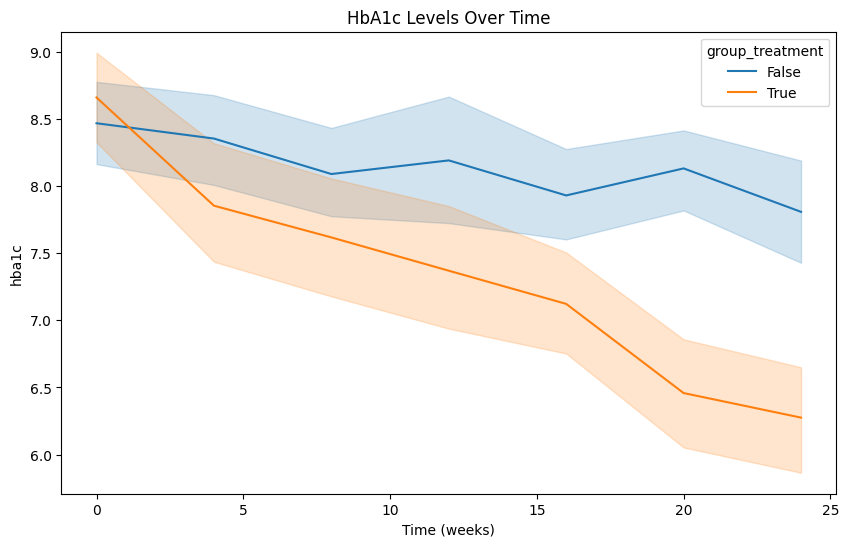

In [10]:
plt.figure(figsize=(10,6))

sns.lineplot(x='time', y='hba1c', hue='group_treatment', data=df)
plt.title('HbA1c Levels Over Time') #Set the x-axis label
plt.xlabel('Time (weeks)') #Set the y-axis label
plt.show() #display the plot

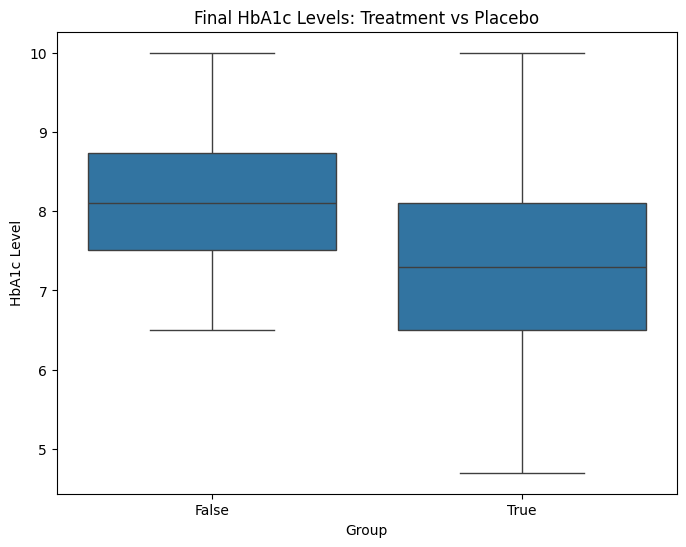

In [11]:
plt.figure(figsize=(8,6))
sns.boxplot(x='group_treatment', y='hba1c', data=df)
plt.title('Final HbA1c Levels: Treatment vs Placebo')
plt.xlabel('Group')
plt.ylabel('HbA1c Level')
plt.show()

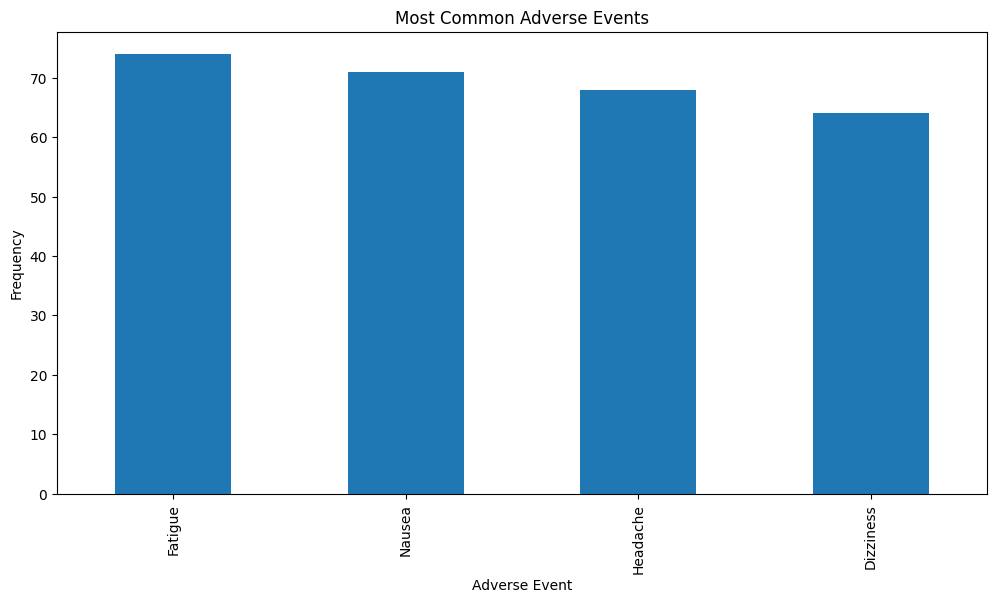

In [12]:
plt.figure(figsize=(12,6))
adverse_events.plot(kind='bar')
plt.title('Most Common Adverse Events')
plt.xlabel('Adverse Event')
plt.ylabel('Frequency')
plt.show()

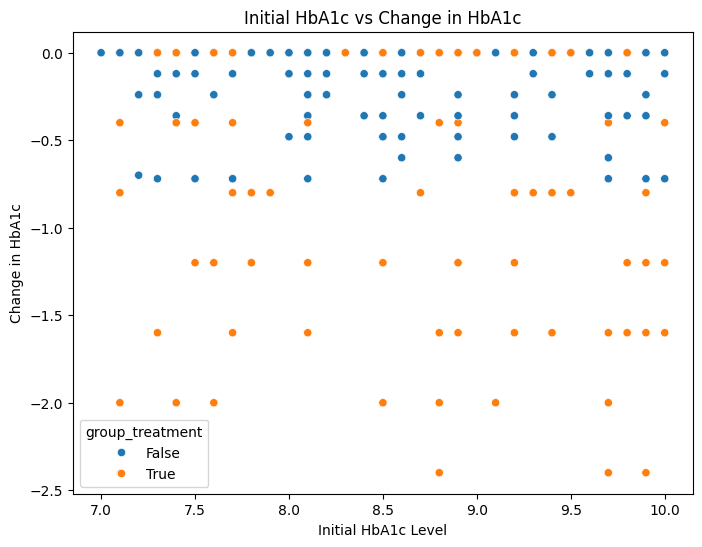

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='initial_hba1c', y='hba1c_change', hue='group_treatment', data=df)
plt.title('Initial HbA1c vs Change in HbA1c')
plt.xlabel('Initial HbA1c Level')
plt.ylabel('Change in HbA1c')
plt.show()

In [14]:
#Statistic Analysis : T-test
t_stat, p_val = stats.ttest_ind(df[df['group_treatment']==1]['hba1c'], df[df['group_treatment']==0]['hba1c'])
print(f"T-test result: t-stat={t_stat}, p-value = {p_val}")

T-test result: t-stat=-6.200485372339337, p-value = 2.0550724738165155e-09


In [15]:
#Perform ANOVA using statsmodels formula API
model = smf.ols('hba1c ~ time + group_treatment', data=df).fit()
aov_table=sm.stats.anova_lm(model, typ=2)
print(aov_table)

                     sum_sq     df          F        PR(>F)
group_treatment   43.836941    1.0  50.782549  9.143732e-12
time              64.254098    1.0  74.434639  5.169343e-16
Residual         236.524596  274.0        NaN           NaN


In [16]:
#Use chi-square test to compare adverse event rates between gorups
adverse_event_table=pd.crosstab(df['group_treatment'],df['adverse_event'])

#create contingency table for adverse events by treatment group
chi2, p, dof, expected = stats.chi2_contingency(adverse_event_table, correction=False)
print(f"Chi-square test results: chi2={chi2}, p-value = {p}")

Chi-square test results: chi2=3.453364951919518, p-value = 0.32686108897063443


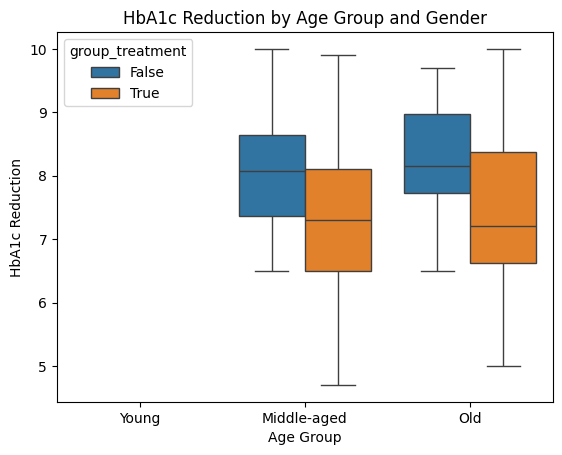

In [17]:
#check if 'age_group' column is missing
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 90], labels=['Young', 'Middle-aged', 'Old'])

#create a boxplot for HbA1c by age group and treatment gorup
sns.boxplot(x='age_group', y='hba1c', hue='group_treatment', data=df)
plt.title('HbA1c Reduction by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('HbA1c Reduction')
plt.show()

In [18]:
#Calculate the correlation between duration of diabetes and HbA1c change
correlation=df['duration_diabetes'].corr(df['hba1c_change'])
print(f"Correlation between Duration of Diabetes and HbA1c Reduction: {correlation}")

Correlation between Duration of Diabetes and HbA1c Reduction: -0.010949212625554507


##### Key Insights

- Overall treatment has a sharper effect in reducing HbA1c Levels over time compared to placebo.
- The most common adverse event is fatigue at a frequency count of 74. However, there is overall a similar spread between different adverse event. Others include nausea, headache, and dizziness. This may require looking into.
- Generally treatment seems to have a slightly higher impact on middle-aged groups than old groups.  
- There is no correlation between duration of diabetes and HbA1c Reduction.


##### Summary

summary:
##### Is the new medication effective in reducing HbA1c levels compared to the placebo?
The diabetes medication clinical trial data shows that the medication group experienced a steep and steady decrease in HbA1c levels from 8.7 to 6.3 across 25 weeks in comparison to the placebo group, which experienced a flatter and inconsistent decrease in HbA1c levels from a peak of 8.5 to 7.9. This reveals that the medication was somewhat effective in dropping HbA1c levels. Something to note is that within the first 4 weeks, the HbA1c levels decreased at the sharpest rate suggesting the medicine had an immediate effect. There is also a larger range between final HbA1c levels for the medication group compared to the placebo group. It may be worthwhile to explore why.

##### Are there any significant differences in the medication's effectiveness based on patient demographics?
The data shows that there is no significant difference in the medication's effectiveness between the Middle-age Aged Group and the Old group. While the Old groups HbA1c levels were generally higher, the reduction was generally similar across both groups. The top 50% of the data is spread out over a much larger range in the old group, suggesting that there are some high values pulling the distribution upward, resulting in positively skewed data for the old group. Further analysis could reveal why that may be the case.

##### What is the safety profile of the new medication? Are there any concerning adverse events?
Out of 277 participants affected with adverse effects, there was approximately and even distribution of adverse effect cases between both medication and placebo groups. This suggests that the medication may not be a causality of those adverse effects. The p-value calculated from the chi-square test results was 0.32, showing that the counts of the adverse events between the two groups are likely due to chance.

##### Is there a correlation between the duration of diabetes and medication's effectiveness?
The data reveals that there is virtually no correlation. Because the correlation (r) value is so close to zero, it shows that the direction is not meaningful.
the negative value technical suggests that as the duration of diabetes increase, the HbA1c reduction very slightly decreases. Further development and research on medication is recommended.



